In [1]:
%load_ext autoreload
%autoreload 2
# import torch
from pathlib import Path
import sys
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import pickle
from scipy.optimize import fmin_l_bfgs_b
import json
import os
from scipy.ndimage import gaussian_filter1d
import glob
from scipy.stats import norm
# import pandas as pd
# import seaborn as sns

# # Function to find the project root directory
# for parent in [Path.cwd().resolve()] + list(Path.cwd().resolve().parents):
#     if (parent / "utils").exists():
#         sys.path.insert(0, str(parent))
#         break

# from utils.pathing import setup_repo_path
# ROOT = setup_repo_path()
# print(f"Project root set to: {ROOT}")
# -----------------------------------------------

# from utils.data import custom_optimizer

In [2]:
# --- Case study groups -------------------------------------------------------
group_2D = ['four_branch_6', 'four_branch_7', 'hat', 'himmelblau']
group_HD = ['nonlinear_oscillator', '2dof_oscillator', 'high_dimensional']

# Assign target lengths (initial 10 samples + AL iterations)
max_length = {
    case: 202 for case in group_2D
}
max_length.update({
    case: 502 for case in group_HD
})
# Combined list (preserves original order)
casestudy = group_2D + group_HD

custom_titles = [
    r'Four-branch, $k=6$', r'Four-branch, $k=7$', 'Hat', 'Himmelblau',
    r'Nonlinear oscillator', '2-DOF Oscillator', r'High-dimensional'
]

real_pf_values = {
    'four_branch_6': 0.004458488011732697,
    'four_branch_7': 0.0022232679883018138,
    'hat': 0.00038667799963150175,
    'himmelblau': 1.65E-4,
    'nonlinear_oscillator': 0.0286178,
    '2dof_oscillator': 0.0047598,
    'high_dimensional': 0.0019820
}

# Base directory of results
# base_results_dir = '/Volumes/Jonathan/MOO_results/Results/results'
base_results_dir = r'D:\\active_train\\review2\\MOO-AL\\notebooks\\results_tracking'

# Active learning settings
n_exp = 15
al_strategy = [
    'moo_reliability', 'moo_knee', 'moo_compromise',
    'moo_eps_ew',
    'eff', 'u', 'erf', 'reif', 'reif2', 'portfolio', 'eier'
]
al_batch = [1]
name_exp = list(range(1, n_exp + 1))

Define the arguments from the experiment variations

In [3]:
# Dictionaries to store results
output_results_dict = {}
config_results_dict = {}

# --- Load all experiments ----------------------------------------------------
for case in casestudy:
    for strategy in al_strategy:
        for batch in al_batch:
            for exp_num in name_exp:

                dir_pattern = os.path.join(
                    base_results_dir, case, f"{strategy}_{batch}_{exp_num}_*"
                )

                matching_dirs = glob.glob(dir_pattern)

                if not matching_dirs:
                    print(f"No directory found for {case}, {strategy}, batch {batch}, exp {exp_num}")
                    continue

                key = f"{case}_{strategy}_{batch}_{exp_num}"

                # Load output.json
                output_json_path = os.path.join(matching_dirs[0], 'output.json')
                if os.path.isfile(output_json_path):
                    with open(output_json_path, 'r') as f:
                        output_results_dict[key] = json.load(f)
                else:
                    print(f"No output.json found for {key}")

                # Load config.json
                config_json_path = os.path.join(matching_dirs[0], 'config.json')
                if os.path.isfile(config_json_path):
                    with open(config_json_path, 'r') as f:
                        config_results_dict[key] = json.load(f)
                else:
                    print(f"No config.json found for {key}")


Load output_dic

In [3]:
name = 'final_runs_11dic2025' #practical, analytical, pareto

with open(f'output_results_dict_{name}.pkl', 'rb') as fp:
    loaded_file = pickle.load(fp)

output_results_dict = loaded_file

In [4]:
incomplete_runs = []

for key, out in output_results_dict.items():
    # 1) Identify the case as the prefix of the key
    case = None
    for c in casestudy:
        if key.startswith(c + "_"):
            case = c
            break

    if case is None:
        print(f"Warning: could not identify case for key={key}")
        continue

    # 2) Remove the case + '_' prefix, then split the rest
    rest = key[len(case) + 1:]  # everything after 'case_'
    # rest should be 'strategy_batch_exp'
    try:
        strategy, batch, exp_num = rest.rsplit("_", 2)
    except ValueError:
        print(f"Warning: could not split strategy/batch/exp for key={key}")
        continue

    # 3) Now you can safely use `case` to look up max_length
    if 'Pf_model' not in out:
        incomplete_runs.append((key, "missing Pf_model"))
        continue

    pf_len = len(out['Pf_model'])
    target_len = max_length[case]-10  # 200 for 2D, 500 for HD

    if pf_len < target_len:
        incomplete_runs.append((key, pf_len))

print("\nIncomplete runs:")
for key, info in incomplete_runs:
    print(f"{key:50s} -> {info}")


Incomplete runs:


Step 1: build relative error dictionary per seed

In [5]:
doe = 10  # initial DoE size (as before)

relative_error_dict = {}  # [case][strategy][exp_num] -> np.array(delta_pf)

for case in casestudy:
    reference_pf = float(real_pf_values[case])
    relative_error_dict[case] = {}

    # decide max length for this case, consistent with previous plots
    if case in group_2D:
        case_max_len = 200
    else:
        case_max_len = 500

    for strategy in al_strategy:
        for exp_num in range(1, n_exp + 1):
            key = f"{case}_{strategy}_1_{exp_num}"
            if key not in output_results_dict:
                continue

            pf_model = np.asarray(
                output_results_dict[key].get('Pf_model', []),
                dtype=float
            )

            if pf_model.size == 0:
                continue

            # truncate to desired max length (if needed)
            max_len = min(len(pf_model), case_max_len)
            pf_model_trunc = pf_model[:max_len]

            # relative Pf error per iteration
            rel_diff = np.abs(pf_model_trunc - reference_pf) / reference_pf

            # store in nested dict
            if strategy not in relative_error_dict[case]:
                relative_error_dict[case][strategy] = {}

            relative_error_dict[case][strategy][exp_num] = rel_diff

In [ ]:
# name = 'testing'
# with open(f'relative_error_dict{name}.pkl', 'wb') as fp:
#     pickle.dump(relative_error_dict, fp)

In [ ]:
# dir = '/Users/jonathan/Documents/MOAL/Experiments/AL_StructuralReliability/'
# dir = 'D:/active_train/compromised/AL_StructuralReliability/'

# name = 'pre_results' #practical, analytical, pareto

# with open(f'relative_error_dict_{name}.pkl', 'rb') as fp:
#     loaded_file = pickle.load(fp)

# relative_error_dict = loaded_file
# doe = 10  # initial DoE size (as before)

one global minimum per strategy → top-5 strategies

In [12]:
# --- Parameters ------------------------------------------------------------
captured_ls = 5         # number of best strategies to capture (top-k)
threshold_factor = 1.0   # scale threshold up (>1) or down (<1). Set threshold_factor = 1.2 if you want the threshold to be 20% looser than that 3rd-minimum.
sigma = 1.5

# --- Step 2: per-strategy global minima, then top-k per case --------------

threshold_dict = {}  # [case] -> { "topk_minima": [...], "threshold_delta_pf": ..., "threshold_entry": ... }

for case in casestudy:
    if case not in relative_error_dict:
        continue

    # decide max length for this case
    if case in group_2D:
        case_max_len = 200
    else:
        case_max_len = 500

    per_strategy_minima = []  # one entry per strategy: its global minimum on median evolution

    # --- compute global minimum of the median evolution per strategy -------
    for strategy, exp_dict in relative_error_dict[case].items():
        if not exp_dict:
            continue

        max_len_available = max(len(arr) for arr in exp_dict.values())
        cap_len = min(max_len_available, case_max_len)

        n_runs = len(exp_dict)
        rel_diff_mat = np.full((n_runs, cap_len), np.nan, dtype=float)

        # rows = experiments
        for row_idx, (exp_num, rel_diff) in enumerate(sorted(exp_dict.items())):
            this_len = min(len(rel_diff), cap_len)
            rel_diff_mat[row_idx, :this_len] = rel_diff[:this_len]

        # median evolution across runs (ignoring NaNs)
        median_raw = np.nanmean(rel_diff_mat, axis=0)
        # median_evolution = gaussian_filter1d(median_raw, sigma=sigma)
        median_evolution = median_raw

        finite_mask = np.isfinite(median_evolution)
        if not np.any(finite_mask):
            continue

        finite_indices = np.where(finite_mask)[0]
        finite_values = median_evolution[finite_mask]

        local_argmin = np.argmin(finite_values)
        it_idx = int(finite_indices[local_argmin])

        delta_pf_min = float(median_evolution[it_idx])
        n_acquired_samples = int(doe + it_idx)

        per_strategy_minima.append({
            "strategy": strategy,
            "delta_pf_min": delta_pf_min,
            "iteration_idx": it_idx,
            "n_acquired_samples": n_acquired_samples,
        })

    if not per_strategy_minima:
        print(f"Warning: no valid minima for case '{case}'.")
        continue

    # sort strategies by their global minimum δPf
    per_strategy_minima_sorted = sorted(per_strategy_minima,
                                        key=lambda d: d["delta_pf_min"])

    # number of strategies we can actually capture
    top_k = min(captured_ls, len(per_strategy_minima_sorted))
    topk = []

    for rank in range(top_k):
        entry = per_strategy_minima_sorted[rank].copy()
        entry["rank"] = rank + 1  # 1 = best
        topk.append(entry)

    # threshold rank index (0-based): captured_ls-1, but capped by available top_k-1
    threshold_rank_index = min(captured_ls - 1, top_k - 1)
    threshold_entry = topk[threshold_rank_index]

    # apply factor to adjust strictness
    base_threshold = threshold_entry["delta_pf_min"]
    threshold_delta_pf = threshold_factor * base_threshold

    threshold_dict[case] = {
        "topk_minima": topk,                    # up to captured_ls strategies
        "captured_ls": captured_ls,
        "threshold_factor": threshold_factor,
        "threshold_delta_pf": threshold_delta_pf,
        "threshold_entry": threshold_entry      # the strategy that defines the base threshold
    }

In [14]:
from pprint import pprint
case = 'hat'
pprint(threshold_dict[case]["topk_minima"])
print("\nThreshold δPf:", threshold_dict[case]["threshold_delta_pf"])
print("\nThreshold entry:", threshold_dict[case]["threshold_entry"])

[{'delta_pf_min': 0.005503634463873365,
  'iteration_idx': 43,
  'n_acquired_samples': 53,
  'rank': 1,
  'strategy': 'reif'},
 {'delta_pf_min': 0.006126365925981093,
  'iteration_idx': 111,
  'n_acquired_samples': 121,
  'rank': 2,
  'strategy': 'moo_knee'},
 {'delta_pf_min': 0.006210507692503272,
  'iteration_idx': 100,
  'n_acquired_samples': 110,
  'rank': 3,
  'strategy': 'reif2'},
 {'delta_pf_min': 0.006551185098707511,
  'iteration_idx': 82,
  'n_acquired_samples': 92,
  'rank': 4,
  'strategy': 'erf'},
 {'delta_pf_min': 0.007045655755682932,
  'iteration_idx': 104,
  'n_acquired_samples': 114,
  'rank': 5,
  'strategy': 'eier'}]

Threshold δPf: 0.007045655755682932

Threshold entry: {'strategy': 'eier', 'delta_pf_min': 0.007045655755682932, 'iteration_idx': 104, 'n_acquired_samples': 114, 'rank': 5}


In [8]:
import numpy as np
import pandas as pd
import random
from typing import Optional, List, Dict, Any

# Ensure required_consecutive is set
required_consecutive = 3
doe = 10 # initial DoE size

# Define the helper function (copied from your input)
def find_first_hit_index(rel_diff: np.ndarray,
                         threshold: float,
                         required_consecutive: int) -> Optional[int]:
    """
    Returns the first index i such that:
        rel_diff[i : i + required_consecutive] <= threshold
    If no such i exists, returns None.
    """
    if rel_diff.size == 0:
        return None

    is_below = rel_diff <= threshold
    max_start = rel_diff.size - required_consecutive

    if max_start < 0:
        return None

    for i in range(max_start + 1):
        if np.all(is_below[i : i + required_consecutive]):
            return i

    return None

# The ranking key used previously (copied from your input)
def seed_sort_key(entry):
    # Treat None delta_at_hit as +inf so non-hits go to the bottom on tie
    delta = entry["delta_at_hit"]
    if delta == None or not np.isfinite(delta):
        delta = np.inf
    return (
        entry["first_hit_samples"],
        delta,
        entry["best_delta_pf"],
        entry["best_samples"],
    )

In [9]:
def generate_one_bootstrapped_global_ranking(
    relative_error_dict: Dict[str, Dict[str, Dict[int, np.ndarray]]],
    threshold_dict: Dict[str, Dict[str, Any]],
    all_strategies: List[str],
    all_limit_states: List[str],
    n_seeds_original: int = 15,
) -> Dict[str, float]:
    """
    Performs one bootstrap iteration, generates 150 bootstrapped runs
    per case, and calculates the global average rank for all strategies.
    Returns: Dict[strategy_name, global_avg_rank]
    """
    bootstrapped_seed_entries = {}
    
    # 1. Generate bootstrapped seeds (15 new seeds per strategy per case)
    for case in all_limit_states:
        if case not in relative_error_dict or case not in threshold_dict:
            continue

        threshold = threshold_dict[case]["threshold_delta_pf"]
        
        # Determine case-specific length/no-hit value
        if case in group_2D:
            case_max_len = 200
            no_hit_value = 201
        else:
            case_max_len = 500
            no_hit_value = 501

        case_seed_entries = []
        
        for strategy in all_strategies:
            original_exp_dict = relative_error_dict[case].get(strategy, {})
            original_keys = list(original_exp_dict.keys())
            
            if not original_keys:
                continue
            
            # --- Bootstrap Resampling with replacement (15 samples) ---
            # Randomly select 15 keys (exp_num) from the original 15
            # Note: A key can be selected multiple times (with replacement)
            bootstrapped_exp_keys = random.choices(original_keys, k=n_seeds_original)
            
            for new_exp_num, original_exp_num in enumerate(bootstrapped_exp_keys, start=1):
                # Use the data from the selected original run
                rel_diff = np.asarray(original_exp_dict[original_exp_num], dtype=float)

                # --- Apply Ranking Logic (as done in your original code) ---
                
                # Truncate and check for data
                cap_len = min(rel_diff.size, case_max_len)
                rel_diff_trunc = rel_diff[:cap_len]
                
                finite_mask = np.isfinite(rel_diff_trunc)
                if not np.any(finite_mask):
                    continue

                # 1) best δPf
                finite_values = rel_diff_trunc[finite_mask]
                best_delta_pf = float(np.min(finite_values))
                best_idx_local = int(np.where(rel_diff_trunc == best_delta_pf)[0][0])
                best_samples = int(doe + best_idx_local)

                # 2) first hit index
                first_hit_idx = find_first_hit_index(
                    rel_diff_trunc, threshold=threshold, required_consecutive=required_consecutive
                )

                if first_hit_idx is not None:
                    reached = True
                    first_hit_samples = int(doe + first_hit_idx)
                    delta_at_hit = float(rel_diff_trunc[first_hit_idx])
                else:
                    reached = False
                    first_hit_samples = no_hit_value
                    delta_at_hit = None

                case_seed_entries.append({
                    "case": case,
                    "strategy": strategy,
                    "exp_num": new_exp_num, # New exp num for the bootstrap sample
                    "global_rank": 0, # Placeholder
                    "first_hit_samples": first_hit_samples,
                    "delta_at_hit": delta_at_hit,
                    "best_delta_pf": best_delta_pf,
                    "best_samples": best_samples,
                })
        
        # Sort and assign ranks for this bootstrapped case (150 total seeds)
        case_seed_entries_sorted = sorted(case_seed_entries, key=seed_sort_key)
        for rank_idx, entry in enumerate(case_seed_entries_sorted, start=1):
            entry["global_rank"] = rank_idx
            
        bootstrapped_seed_entries[case] = case_seed_entries_sorted
        
    # 2. Compute Global Average Ranking from bootstrapped seeds
    
    # Initialize DataFrame to store average ranks for this bootstrap
    rank_df = pd.DataFrame(index=all_strategies, columns=all_limit_states, dtype=float)

    for case in all_limit_states:
        seeds = bootstrapped_seed_entries.get(case, [])
        if not seeds:
            continue

        ranks_by_strategy = {}
        for s in seeds:
            ranks_by_strategy.setdefault(s["strategy"], []).append(s["global_rank"])

        for strat, ranks in ranks_by_strategy.items():
            avg_rank = float(np.mean(ranks))
            rank_df.loc[strat, case] = avg_rank
            
    # Calculate the Global Average Rank (mean across limit states)
    global_ranks = rank_df.mean(axis=1, skipna=True).to_dict()
    
    return global_ranks

In [10]:
# --- Parameters for the bootstrap analysis ---
N_BOOTSTRAPS = 1000
# Ensure group_2D and group_HD are accessible here (based on your setup)
# group_2D = ['four_branch_6', 'four_branch_7', 'hat', 'himmelblau']
# group_HD = ['nonlinear_oscillator', '2dof_oscillator', 'high_dimensional'] 

all_strategies = [
    'moo_reliability', 'moo_knee', 'moo_compromise',
    'moo_eps_ew',
    'eff', 'u', 'erf', 'reif', 'reif2', 'portfolio'
]

# Note: 'high_dimensional' was excluded in your final ranking
all_limit_states = [
    'four_branch_6', 'four_branch_7',
    'hat', 'himmelblau',
    'nonlinear_oscillator', '2dof_oscillator',
]
# ---------------------------------------------

# List to store the global rank for each strategy for all N_BOOTSTRAPS
all_bootstrapped_global_ranks = {
    strategy: [] for strategy in all_strategies
}

print(f"Starting {N_BOOTSTRAPS} bootstrap iterations...")

for b in range(N_BOOTSTRAPS):
    if (b + 1) % 100 == 0:
        print(f"  ... Iteration {b + 1}/{N_BOOTSTRAPS}")

    # Generate one set of global ranks
    try:
        global_ranks = generate_one_bootstrapped_global_ranking(
            relative_error_dict, threshold_dict, all_strategies, all_limit_states
        )
        
        # Store the global rank for this bootstrap
        for strategy, rank in global_ranks.items():
            if not np.isnan(rank):
                all_bootstrapped_global_ranks[strategy].append(rank)

    except Exception as e:
        # Handle potential errors during a bootstrap run
        # print(f"Error in bootstrap {b}: {e}")
        continue

print("\nBootstrap complete. Calculating probability matrix.")

# --- Calculate Pairwise Probability Matrix ---

# Initialize the 10x10 matrix (strategies vs. strategies)
probability_matrix = pd.DataFrame(
    0.0, index=all_strategies, columns=all_strategies
)

# For every pair of strategies (A, B)
for strat_A in all_strategies:
    for strat_B in all_strategies:
        if strat_A == strat_B:
            continue
            
        ranks_A = all_bootstrapped_global_ranks[strat_A]
        ranks_B = all_bootstrapped_global_ranks[strat_B]
        
        # Align arrays: only compare ranks from bootsraps where both strategies 
        # had valid data (should be most of the time)
        min_len = min(len(ranks_A), len(ranks_B))
        ranks_A = ranks_A[:min_len]
        ranks_B = ranks_B[:min_len]

        if min_len == 0:
            continue

        # Strategy A is "better" than Strategy B if Rank A < Rank B (lower rank = better)
        A_is_better = np.sum(np.array(ranks_A) < np.array(ranks_B))
        
        # Probability P(A is better than B) = (Count where Rank A < Rank B) / (Total comparisons)
        probability = A_is_better / min_len
        probability_matrix.loc[strat_A, strat_B] = probability


Starting 1000 bootstrap iterations...
  ... Iteration 100/1000
  ... Iteration 200/1000
  ... Iteration 300/1000
  ... Iteration 400/1000
  ... Iteration 500/1000
  ... Iteration 600/1000
  ... Iteration 700/1000
  ... Iteration 800/1000
  ... Iteration 900/1000
  ... Iteration 1000/1000

Bootstrap complete. Calculating probability matrix.


In [11]:
# --- Print Final Results ---
print("--- Pairwise Probability Matrix: P(Row Strategy is Better than Column Strategy) ---")
# Better visualization by rounding and sorting by overall average rank
average_ranks_per_strategy = {
    s: np.mean(all_bootstrapped_global_ranks[s]) 
    for s in all_strategies if all_bootstrapped_global_ranks[s]
}

sorted_strategies = sorted(average_ranks_per_strategy, key=average_ranks_per_strategy.get)

# Reorder matrix for best visual effect
probability_matrix_sorted = probability_matrix.loc[sorted_strategies, sorted_strategies]

print(probability_matrix_sorted.round(3).to_string())

--- Pairwise Probability Matrix: P(Row Strategy is Better than Column Strategy) ---
                 portfolio  moo_reliability    erf    eff   reif  moo_eps_ew  reif2      u  moo_knee  moo_compromise
portfolio            0.000            0.911  0.995  0.996  0.993       0.998  1.000  1.000     1.000           1.000
moo_reliability      0.089            0.000  0.908  0.907  0.915       0.958  0.993  1.000     1.000           1.000
erf                  0.005            0.092  0.000  0.575  0.577       0.721  0.934  1.000     1.000           1.000
eff                  0.004            0.093  0.424  0.000  0.496       0.630  0.900  1.000     0.999           1.000
reif                 0.007            0.085  0.423  0.502  0.000       0.646  0.894  1.000     0.999           1.000
moo_eps_ew           0.002            0.042  0.278  0.370  0.354       0.000  0.832  1.000     1.000           1.000
reif2                0.000            0.007  0.066  0.100  0.106       0.168  0.000  0.979     0.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20736\1647476502.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


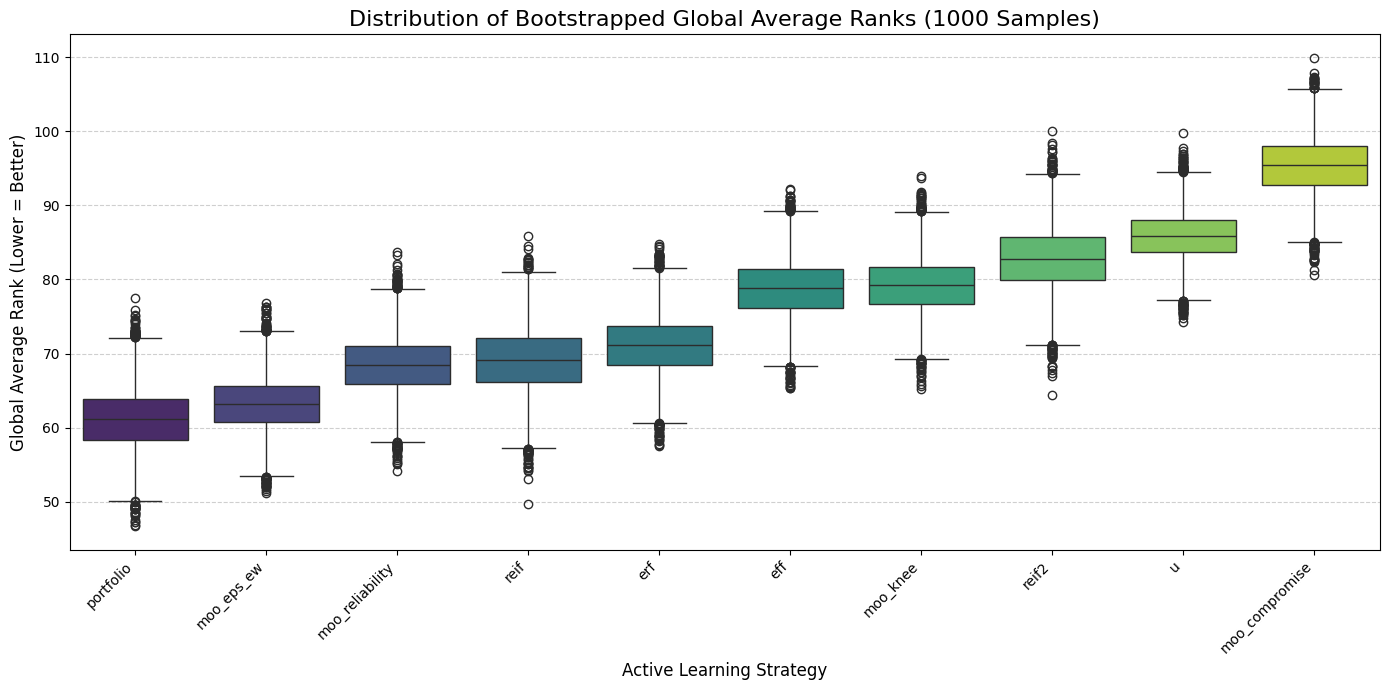

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- 1. Prepare Data for Plotting (Convert to Long Format DataFrame) ---

# The data is currently a dictionary of lists. We convert it to a DataFrame.
plot_data = pd.DataFrame(all_bootstrapped_global_ranks).melt(
    var_name='Strategy', 
    value_name='Global Rank'
)

# --- 2. Determine Plotting Order (Strategies sorted by mean rank) ---

# Calculate the mean rank for sorting the x-axis, making comparisons easier
average_ranks_per_strategy = {
    s: np.mean(all_bootstrapped_global_ranks[s]) 
    for s in all_strategies if all_bootstrapped_global_ranks[s]
}
sorted_strategies = sorted(
    average_ranks_per_strategy, 
    key=average_ranks_per_strategy.get
)

# --- 3. Generate the Boxplot ---

plt.figure(figsize=(14, 7))

sns.boxplot(
    x='Strategy', 
    y='Global Rank', 
    data=plot_data, 
    order=sorted_strategies,  # Sort by the actual average rank
    palette='viridis'         # A nice color scheme
)

# --- 4. Customize Plot ---

plt.title('Distribution of Bootstrapped Global Average Ranks (1000 Samples)', fontsize=16)
plt.ylabel('Global Average Rank (Lower = Better)', fontsize=12)
plt.xlabel('Active Learning Strategy', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Display the plot
plt.show()